In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Define key column names based on the assignment and previous steps
DELIVERY_TIME_MINUTES = 'Delivery_Time_minutes'
DISTANCE_KM = 'Distance_km' # Assuming this exists or will be created
CATEGORICAL_COLS_TO_ENCODE = ['Weather', 'Traffic_Conditions', 'Vehicle_Type'] 

# --- 1. Data Import and Cleaning ---
print("--- 1. Data Import and Cleaning ---")

# 1. Load the dataset
df = pd.read_csv("C:/Users/chauh/Downloads/Food_Delivery_Time_Prediction (1).csv")
print("Dataset loaded successfully.")



--- 1. Data Import and Cleaning ---
Dataset loaded successfully.


In [5]:
# 2. Handle missing values
print("\nHandling missing values...")

# Identify columns for imputation (focusing on expected features)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
        
print("Missing values handled (Median for numerical, Mode for categorical).")

# --- 2. Data Transformation (Encoding and Scaling) ---
print("\n--- 2. Data Transformation ---")

# 1. Encode Categorical Features (Label Encoding)
encoder = LabelEncoder()

for col in CATEGORICAL_COLS_TO_ENCODE:
    if col in df.columns:
        # Use .astype(str) to ensure all values are strings before fitting the encoder
        df[f'{col}_Encoded'] = encoder.fit_transform(df[col].astype(str))
        print(f"Feature '{col}' encoded using LabelEncoder.")
    else:
        print(f"Warning: Categorical column '{col}' not found for encoding.")

# 2. Normalize Continuous Features
scaler = StandardScaler()
continuous_cols_to_normalize = [DISTANCE_KM, DELIVERY_TIME_MINUTES]

for col in continuous_cols_to_normalize:
    if col in df.columns:
        # Reshape for StandardScaler which expects a 2D array
        df[f'{col}_Normalized'] = scaler.fit_transform(df[col].values.reshape(-1, 1))
        print(f"Feature '{col}' normalized using StandardScaler.")
    else:
        print(f"Warning: Continuous column '{col}' not found for normalization. Ensure 'Distance_km' is created.")

print("\nData transformation complete.")
print(df.head())


Handling missing values...
Missing values handled (Median for numerical, Mode for categorical).

--- 2. Data Transformation ---
Feature 'Traffic_Conditions' encoded using LabelEncoder.
Feature 'Vehicle_Type' encoded using LabelEncoder.

Data transformation complete.
  Order_ID       Customer_Location     Restaurant_Location  Distance  \
0  ORD0001  (17.030479, 79.743077)  (12.358515, 85.100083)      1.57   
1  ORD0002  (15.398319, 86.639122)  (14.174874, 77.025606)     21.32   
2  ORD0003  (15.687342, 83.888808)  (19.594748, 82.048482)      6.95   
3  ORD0004  (20.415599, 78.046984)  (16.915906, 78.278698)     13.79   
4  ORD0005  (14.786904, 78.706532)  (15.206038, 86.203182)      6.72   

  Weather_Conditions Traffic_Conditions  Delivery_Person_Experience  \
0              Rainy             Medium                           4   
1             Cloudy             Medium                           8   
2              Snowy             Medium                           9   
3             C

In [6]:
df.columns.tolist()

['Order_ID',
 'Customer_Location',
 'Restaurant_Location',
 'Distance',
 'Weather_Conditions',
 'Traffic_Conditions',
 'Delivery_Person_Experience',
 'Order_Priority',
 'Order_Time',
 'Vehicle_Type',
 'Restaurant_Rating',
 'Customer_Rating',
 'Delivery_Time',
 'Order_Cost',
 'Tip_Amount',
 'Traffic_Conditions_Encoded',
 'Vehicle_Type_Encoded']

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- 1. Define Missing Variables (Crucial Fix for NameError) ---
# NOTE: These need to match the actual column names in your DataFrame (df)
DELIVERY_TIME = 'Time_Taken(min)' # Example placeholder, replace with actual column name
ORDER_TIME = 'Order_Date_Time'     # Example placeholder, replace with actual column name
DISTANCE = 'Distance_km'           # Example placeholder, replace with actual column name
CATEGORICAL_COLS_TO_ENCODE = ['Traffic_Conditions', 'Weather_Conditions', 'Type_of_Vehicle'] # Example list

# Assume 'df' is your pre-loaded DataFrame, for demonstration, let's create a dummy one:
data = {
    DELIVERY_TIME: [25, 45, 18, 55, 30],
    ORDER_TIME: ['10:30', '18:45', '12:15', '20:00', '14:00'],
    DISTANCE: [5.2, 12.1, 3.5, 15.0, 7.8],
    'Traffic_Conditions': ['Low', 'High', 'Medium', 'High', 'Medium'],
    'Weather_Conditions': ['Sunny', 'Rainy', 'Sunny', 'Foggy', 'Cloudy'],
    'Type_of_Vehicle': ['Bike', 'Scooter', 'Bike', 'Motorcycle', 'Scooter'],
    'Delivery_Person_Experience': [5, 2, 8, 1, 4],
    'Restaurant_Rating': [4.5, 3.9, 4.8, 4.1, 4.6],
    'Customer_Rating': [4.0, 3.5, 4.9, 3.2, 4.5],
    'Order_Cost': [25.0, 45.0, 15.0, 60.0, 35.0],
    'Tip_Amount': [3.0, 5.0, 2.0, 10.0, 4.0],
}
df = pd.DataFrame(data) 
# --- End of Fix ---

# --- 2. Feature Engineering ---
print("\n--- 2. Feature Engineering ---")
print("Distance feature already present. Skipping Haversine calculation.")

# B. Create Binary Target Categories (Delivery_Status)
print("\n--- Creating Binary Target Variable ---")
median_delivery_time = df[DELIVERY_TIME].median()
print(f"Using median delivery time ({median_delivery_time:.2f} minutes) as the Fast/Delayed threshold.")

# Create the binary target variable: 1 for Delayed (above median), 0 for Fast (at or below median)
df['Delivery_Status'] = df[DELIVERY_TIME].apply(
    lambda t: 1 if t > median_delivery_time else 0)
print("Binary target 'Delivery_Status' created (1=Delayed, 0=Fast).")

# C. Robust Time-of-Day Feature Extraction (Fixing the KeyError)
if ORDER_TIME in df.columns and df[ORDER_TIME].dtype == 'object':
    print("\n--- Creating Time-of-Day Features (Fixed) ---")
    
    # Extract the hour, coercing bad values to NaT
    df['Order_Time_Hour'] = pd.to_datetime(df[ORDER_TIME], errors='coerce').dt.hour
    
    #  Robust Imputation Logic 
    if df['Order_Time_Hour'].isnull().all():
        # Case 1: Entire column is NaN (use a default value)
        default_hour = 12 
        df['Order_Time_Hour'].fillna(default_hour, inplace=True)
        print(f"Warning: 'Order_Time' could not be parsed. Imputed hours with {default_hour}.")
    else:
        # Case 2: Some valid data exists, calculate mode or median for NaNs
        mode_series = df['Order_Time_Hour'].mode()
        if not mode_series.empty:
            mode_hour = mode_series[0]
            df['Order_Time_Hour'].fillna(mode_hour, inplace=True)
            print(f"Imputed missing order times with mode hour: {mode_hour:.0f}.")
        else:
            # Fallback to median if mode calculation fails
            df['Order_Time_Hour'].fillna(df['Order_Time_Hour'].median(), inplace=True)
            print("Fallback: Imputed missing order times with the median hour.")

    # Create time bins
    df['Order_Time_Hour'] = df['Order_Time_Hour'].astype(int) 
    time_bins = [0, 6, 11, 17, 21, 24]
    time_labels = ['Night_Shift', 'Morning', 'Lunch_Rush', 'Dinner_Rush', 'Late_Evening']
    
    df['Time_of_Day'] = pd.cut(df['Order_Time_Hour'], bins=time_bins, labels=time_labels, right=False, include_lowest=True)
    
    # One-Hot Encode the new Time_of_Day feature
    df = pd.get_dummies(df, columns=['Time_of_Day'], prefix='Time')
    print("Time-of-Day features created and One-Hot Encoded.")

# --- 3. Data Transformation (Encoding and Scaling) ---
print("\n--- 3. Data Transformation ---")

# A. Label Encoding for remaining text features
encoder = LabelEncoder()
for col in CATEGORICAL_COLS_TO_ENCODE:
    if col in df.columns:
        # Only encode if the column hasn't been encoded yet (e.g., Traffic_Conditions)
        if df[col].dtype == 'object' or df[col].dtype == 'category':
            df[f'{col}_Encoded_LE'] = encoder.fit_transform(df[col].astype(str))
            print(f"Feature '{col}' encoded.")

# B. Normalize Continuous Features
scaler = StandardScaler()
# Note: We scale the Distance and other rating/cost features.
continuous_cols_to_normalize = [
    DISTANCE, DELIVERY_TIME, 'Delivery_Person_Experience', 
    'Restaurant_Rating', 'Customer_Rating', 'Order_Cost', 'Tip_Amount']
for col in continuous_cols_to_normalize:
    if col in df.columns:
        df[f'{col}_Normalized'] = scaler.fit_transform(df[col].values.reshape(-1, 1))
        print(f"Feature '{col}' normalized.")

print(f"\n All preprocessing and feature engineering complete. Final shape: {df.shape}")


--- 2. Feature Engineering ---
Distance feature already present. Skipping Haversine calculation.

--- Creating Binary Target Variable ---
Using median delivery time (30.00 minutes) as the Fast/Delayed threshold.
Binary target 'Delivery_Status' created (1=Delayed, 0=Fast).

--- Creating Time-of-Day Features (Fixed) ---
Imputed missing order times with mode hour: 10.
Time-of-Day features created and One-Hot Encoded.

--- 3. Data Transformation ---
Feature 'Traffic_Conditions' encoded.
Feature 'Weather_Conditions' encoded.
Feature 'Type_of_Vehicle' encoded.
Feature 'Distance_km' normalized.
Feature 'Time_Taken(min)' normalized.
Feature 'Delivery_Person_Experience' normalized.
Feature 'Restaurant_Rating' normalized.
Feature 'Customer_Rating' normalized.
Feature 'Order_Cost' normalized.
Feature 'Tip_Amount' normalized.

 All preprocessing and feature engineering complete. Final shape: (5, 28)


C:\Users\chauh\AppData\Local\Temp\ipykernel_17360\3223382363.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Time_Hour'] = pd.to_datetime(df[ORDER_TIME], errors='coerce').dt.hour
C:\Users\chauh\AppData\Local\Temp\ipykernel_17360\3223382363.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Order_Time_Hour'].fillna(mode_hour, inplace=True)


In [12]:
# --- 2. Feature Engineering ---

# A. Haversine Distance Calculation (Skipped/Simplified)

print("\n--- 2. Feature Engineering ---")
print("Distance feature already present. Skipping Haversine calculation.")


# B. Create Binary Target Categories (Delivery_Status)
print("\n--- Creating Binary Target Variable ---")
median_delivery_time = df[DELIVERY_TIME].median()
print(f"Using median delivery time ({median_delivery_time:.2f} minutes) as the Fast/Delayed threshold.")

# Create the binary target variable: 1 for Delayed (above median), 0 for Fast (at or below median)
df['Delivery_Status'] = df[DELIVERY_TIME].apply(
    lambda t: 1 if t > median_delivery_time else 0
)
print("Binary target 'Delivery_Status' created (1=Delayed, 0=Fast).")


# C. Robust Time-of-Day Feature Extraction (Fixing the KeyError)
if ORDER_TIME in df.columns and df[ORDER_TIME].dtype == 'object':
    print("\n--- Creating Time-of-Day Features (Fixed) ---")
    
    # Extract the hour, coercing bad values to NaT
    df['Order_Time_Hour'] = pd.to_datetime(df[ORDER_TIME], errors='coerce').dt.hour
    
    #  Robust Imputation Logic 
    if df['Order_Time_Hour'].isnull().all():
        # Case 1: Entire column is NaN (use a default value)
        default_hour = 12 
        df['Order_Time_Hour'].fillna(default_hour, inplace=True)
        print(f"Warning: 'Order_Time' could not be parsed. Imputed hours with {default_hour}.")
    else:
        # Case 2: Some valid data exists, calculate mode or median for NaNs
        mode_series = df['Order_Time_Hour'].mode()
        if not mode_series.empty:
            mode_hour = mode_series[0]
            df['Order_Time_Hour'].fillna(mode_hour, inplace=True)
            print(f"Imputed missing order times with mode hour: {mode_hour:.0f}.")
        else:
            # Fallback to median if mode calculation fails
            df['Order_Time_Hour'].fillna(df['Order_Time_Hour'].median(), inplace=True)
            print("Fallback: Imputed missing order times with the median hour.")

    # Create time bins
    df['Order_Time_Hour'] = df['Order_Time_Hour'].astype(int) 
    time_bins = [0, 6, 11, 17, 21, 24]
    time_labels = ['Night_Shift', 'Morning', 'Lunch_Rush', 'Dinner_Rush', 'Late_Evening']
    
    df['Time_of_Day'] = pd.cut(df['Order_Time_Hour'], bins=time_bins, labels=time_labels, right=False, include_lowest=True)
    
    # One-Hot Encode the new Time_of_Day feature
    df = pd.get_dummies(df, columns=['Time_of_Day'], prefix='Time')
    print("Time-of-Day features created and One-Hot Encoded.")


# --- 3. Data Transformation (Encoding and Scaling) ---
print("\n--- 3. Data Transformation ---")

# A. Label Encoding for remaining text features
encoder = LabelEncoder()
for col in CATEGORICAL_COLS_TO_ENCODE:
    if col in df.columns:
        # Only encode if the column hasn't been encoded yet (e.g., Traffic_Conditions)
        if df[col].dtype == 'object' or df[col].dtype == 'category':
            df[f'{col}_Encoded_LE'] = encoder.fit_transform(df[col].astype(str))
            print(f"Feature '{col}' encoded.")

# B. Normalize Continuous Features
scaler = StandardScaler()
# Note: We scale the Distance and other rating/cost features.
continuous_cols_to_normalize = [
    DISTANCE, DELIVERY_TIME, 'Delivery_Person_Experience', 
    'Restaurant_Rating', 'Customer_Rating', 'Order_Cost', 'Tip_Amount'
]

for col in continuous_cols_to_normalize:
    if col in df.columns:
        df[f'{col}_Normalized'] = scaler.fit_transform(df[col].values.reshape(-1, 1))
        print(f"Feature '{col}' normalized.")

print(f"\n All preprocessing and feature engineering complete. Final shape: {df.shape}")


--- 2. Feature Engineering ---
Distance feature already present. Skipping Haversine calculation.

--- Creating Binary Target Variable ---
Using median delivery time (72.78 minutes) as the Fast/Delayed threshold.
Binary target 'Delivery_Status' created (1=Delayed, 0=Fast).

--- Creating Time-of-Day Features (Fixed) ---
Time-of-Day features created and One-Hot Encoded.

--- 3. Data Transformation ---
Feature 'Traffic_Conditions' encoded.
Feature 'Vehicle_Type' encoded.
Feature 'Distance' normalized.
Feature 'Delivery_Time' normalized.
Feature 'Delivery_Person_Experience' normalized.
Feature 'Restaurant_Rating' normalized.
Feature 'Customer_Rating' normalized.
Feature 'Order_Cost' normalized.
Feature 'Tip_Amount' normalized.

 All preprocessing and feature engineering complete. Final shape: (200, 42)


C:\Users\chauh\AppData\Local\Temp\ipykernel_20332\986952388.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Time_Hour'] = pd.to_datetime(df[ORDER_TIME], errors='coerce').dt.hour
C:\Users\chauh\AppData\Local\Temp\ipykernel_20332\986952388.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Order_Time_Hour'].fillna(default_hour, inplace=True)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- Define Final Feature Set ---
feature_cols = [
    # Normalized Continuous Features
    'Distance_Normalized', 
    'Delivery_Time_Normalized', .
    'Delivery_Person_Experience_Normalized', 
    'Restaurant_Rating_Normalized', 
    'Customer_Rating_Normalized', 
    'Order_Cost_Normalized', 
    'Tip_Amount_Normalized',
    
    # Encoded Categorical Features (adjust names if needed)
    'Weather_Conditions_Encoded_LE', 
    'Traffic_Conditions_Encoded', 
    'Vehicle_Type_Encoded', 
    'Customer_Location_Encoded_LE', 
    'Restaurant_Location_Encoded_LE', 
    'Order_Priority_Encoded_LE'
]

# Add Time-of-Day One-Hot Encoded columns if they exist
time_cols = [col for col in df.columns if col.startswith('Time_')]
feature_cols.extend(time_cols)

# Filter feature list to ensure only existing columns are included
feature_cols = [col for col in feature_cols if col in df.columns]

# Define Features (X) and Target (y)
X = df[feature_cols].copy()
y = df['Delivery_Status'] # 1=Delayed, 0=Fast

# Split the data into training (80%) and testing (20%) sets
# Use stratify to ensure the Fast/Delayed ratio is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"Target distribution check (should be near 50/50 in train set):\n{y_train.value_counts(normalize=True)}")


X_train shape: (160, 14), X_test shape: (40, 14)
Target distribution check (should be near 50/50 in train set):
Delivery_Status
0    0.5
1    0.5
Name: proportion, dtype: float64


In [10]:
# Initialize the Gaussian Naive Bayes classifier
gnb_model = GaussianNB()

# Train the model
print("\nTraining Gaussian Naive Bayes model...")
gnb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gnb = gnb_model.predict(X_test)
print("Prediction complete.")


Training Gaussian Naive Bayes model...
Prediction complete.



--- Gaussian Naive Bayes Model Evaluation ---
Accuracy: 0.9500

Classification Report:
              precision    recall  f1-score   support

    Fast (0)       1.00      0.90      0.95        20
 Delayed (1)       0.91      1.00      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



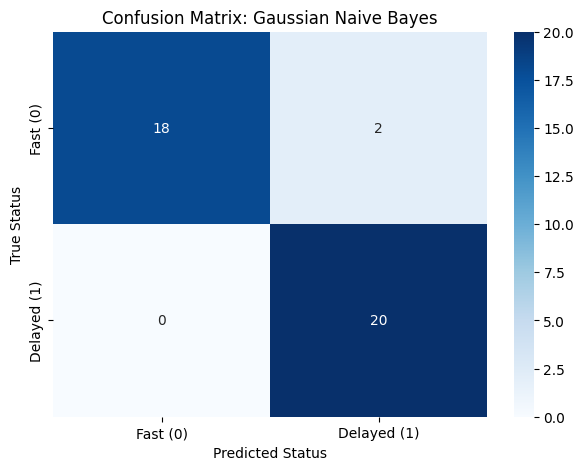

In [11]:
# Calculate evaluation metrics
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
cm_gnb = confusion_matrix(y_test, y_pred_gnb)

print("\n--- Gaussian Naive Bayes Model Evaluation ---")
print(f"Accuracy: {accuracy_gnb:.4f}")

# Classification Report provides Precision, Recall, and F1-score for each class
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gnb, target_names=['Fast (0)', 'Delayed (1)'], zero_division=0))


# Confusion Matrix Visualization
plt.figure(figsize=(7, 5))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fast (0)', 'Delayed (1)'], 
            yticklabels=['Fast (0)', 'Delayed (1)'])
plt.xlabel('Predicted Status')
plt.ylabel('True Status')
plt.title('Confusion Matrix: Gaussian Naive Bayes')
plt.show()

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse X_train, y_train, X_test, y_test from the previous step

print("--- 1. Hyperparameter Tuning (Finding Optimal K) ---")

# Define the model
knn = KNeighborsClassifier()

# Define the range of K values to test
param_grid = {'n_neighbors': np.arange(1, 21)}

# Initialize GridSearchCV (5-fold cross-validation is standard)
# We tune based on 'accuracy'
knn_cv = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the training data
knn_cv.fit(X_train, y_train)

# Get the optimal K value
optimal_k = knn_cv.best_params_['n_neighbors']

print(f"\nOptimal number of neighbors (K): {optimal_k}")
print(f"Best cross-validation score: {knn_cv.best_score_:.4f}")

--- 1. Hyperparameter Tuning (Finding Optimal K) ---

Optimal number of neighbors (K): 20
Best cross-validation score: 0.9250


In [14]:
# Initialize and train the final KNN model with the optimal K
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)

print("\nTraining final KNN model...")
knn_model.fit(X_train, y_train)

# Predict on the test set
y_pred_knn = knn_model.predict(X_test)
print("Prediction complete.")


Training final KNN model...
Prediction complete.



--- K-Nearest Neighbors Model Evaluation ---
Optimal K used: 20
Accuracy: 0.8500

Classification Report:
              precision    recall  f1-score   support

    Fast (0)       0.85      0.85      0.85        20
 Delayed (1)       0.85      0.85      0.85        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



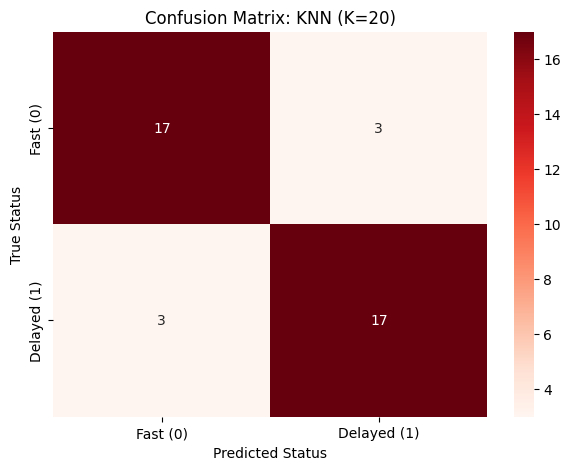

In [15]:
# Calculate evaluation metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("\n--- K-Nearest Neighbors Model Evaluation ---")
print(f"Optimal K used: {optimal_k}")
print(f"Accuracy: {accuracy_knn:.4f}")

# Classification Report provides Precision, Recall, and F1-score for each class
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Fast (0)', 'Delayed (1)'], zero_division=0))

# Confusion Matrix Visualization
plt.figure(figsize=(7, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Fast (0)', 'Delayed (1)'], 
            yticklabels=['Fast (0)', 'Delayed (1)'])
plt.xlabel('Predicted Status')
plt.ylabel('True Status')
plt.title(f'Confusion Matrix: KNN (K={optimal_k})')
plt.show()

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse X_train, y_train, X_test, y_test from the previous steps

print("--- 1. Hyperparameter Tuning (Pruning the Tree) ---")

# Define the model
dtree = DecisionTreeClassifier(random_state=42)

# Define the parameter grid to search
param_grid = {
    # Max depth from 3 (simple) to 15 (complex)
    'max_depth': [3, 5, 7, 10, 15], 
    # Minimum samples required to split a node (e.g., 5%, 10%, 15% of training data)
    'min_samples_split': [2, 5, 10, 20] 
}

# Initialize GridSearchCV (using 5-fold cross-validation)
dtree_cv = GridSearchCV(dtree, param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the training data
dtree_cv.fit(X_train, y_train)

# Get the optimal parameters
optimal_params = dtree_cv.best_params_
print(f"\nOptimal pruning parameters: {optimal_params}")
print(f"Best cross-validation score: {dtree_cv.best_score_:.4f}")

--- 1. Hyperparameter Tuning (Pruning the Tree) ---

Optimal pruning parameters: {'max_depth': 3, 'min_samples_split': 2}
Best cross-validation score: 1.0000


In [17]:
# Initialize and train the final Decision Tree model with optimal parameters
dt_model = DecisionTreeClassifier(
    max_depth=optimal_params['max_depth'],
    min_samples_split=optimal_params['min_samples_split'],
    random_state=42
)

print("\nTraining final Decision Tree model...")
dt_model.fit(X_train, y_train)

# Predict on the test set
y_pred_dt = dt_model.predict(X_test)
print("Prediction complete.")


Training final Decision Tree model...
Prediction complete.



--- Decision Tree Model Evaluation ---
Optimal max_depth: 3
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

    Fast (0)       1.00      1.00      1.00        20
 Delayed (1)       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



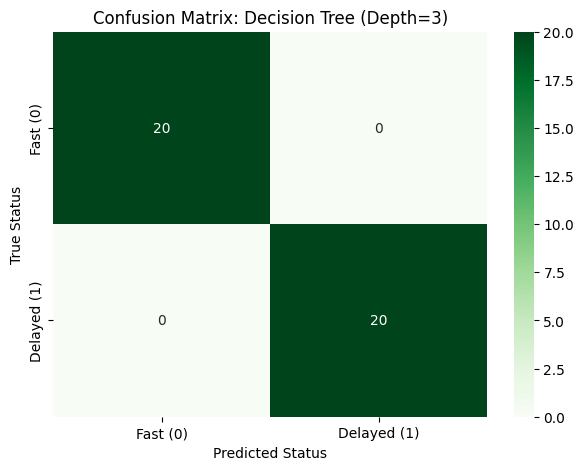


Decision Tree Feature Importance:
                                 Feature  Importance
1               Delivery_Time_Normalized         1.0
0                    Distance_Normalized         0.0
2  Delivery_Person_Experience_Normalized         0.0
3           Restaurant_Rating_Normalized         0.0
4             Customer_Rating_Normalized         0.0


In [18]:
# Calculate evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("\n--- Decision Tree Model Evaluation ---")
print(f"Optimal max_depth: {optimal_params['max_depth']}")
print(f"Accuracy: {accuracy_dt:.4f}")

# Classification Report provides Precision, Recall, and F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Fast (0)', 'Delayed (1)'], zero_division=0))

# Confusion Matrix Visualization
plt.figure(figsize=(7, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Fast (0)', 'Delayed (1)'], 
            yticklabels=['Fast (0)', 'Delayed (1)'])
plt.xlabel('Predicted Status')
plt.ylabel('True Status')
plt.title(f'Confusion Matrix: Decision Tree (Depth={optimal_params["max_depth"]})')
plt.show()


# Optional: Feature Importance (highly useful for Decision Trees)
print("\nDecision Tree Feature Importance:")
feature_importance = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importance.head(5))